In [9]:
from sklearn.feature_extraction.text import CountVectorizer
v = CountVectorizer(ngram_range=(2, 2))
v.fit(["Thor Hathodawala is looking for a job!"])
v.vocabulary_

{'thor hathodawala': 4,
 'hathodawala is': 1,
 'is looking': 2,
 'looking for': 3,
 'for job': 0}

In [10]:
corpus = [
    "Thor ate pizza",
    "Loki is tall",
    "Loki is eating pizza"
]

In [12]:
import spacy
nlp = spacy.load("en_core_web_sm")
def preprocess(text):
    doc = nlp(text)

    filtered_tokens = []
    
    for token in doc:
        if token.is_stop and token.is_punct:
            continue
        filtered_tokens.append(token.lemma_)
    return " ".join(filtered_tokens)

In [15]:
preprocess("Loki is eating pizza")

'Loki be eat pizza'

In [17]:
corpus_preprocessed = [preprocess(text) for text in corpus]
corpus_preprocessed

['thor eat pizza', 'Loki be tall', 'Loki be eat pizza']

In [18]:
v = CountVectorizer(ngram_range=(1, 2))
v.fit(corpus_preprocessed)
v.vocabulary_

{'thor': 9,
 'eat': 3,
 'pizza': 7,
 'thor eat': 10,
 'eat pizza': 4,
 'loki': 5,
 'be': 0,
 'tall': 8,
 'loki be': 6,
 'be tall': 2,
 'be eat': 1}

In [21]:
v.transform(["Thor ate pizza"]).toarray()

array([[0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0]])

In [22]:
v.transform(["Hulk ate pizza"]).toarray()

array([[0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0]])

In [23]:
import pandas as pd
df = pd.read_json("news_dataset.json")
df.head()

,text,category
0,Watching Schrödinger's Cat Die University of C...,SCIENCE
1,WATCH: Freaky Vortex Opens Up In Flooded Lake,SCIENCE
2,Entrepreneurs Today Don't Need a Big Budget to...,BUSINESS
3,These Roads Could Recharge Your Electric Car A...,BUSINESS
4,Civilian 'Guard' Fires Gun While 'Protecting' ...,CRIME


In [24]:
df.category.value_counts()

category
BUSINESS    4254
SPORTS      4167
CRIME       2893
SCIENCE     1381
Name: count, dtype: int64

In [27]:
min_samples = 1381
df_business = df[df.category=='BUSINESS'].sample(min_samples, random_state=20)
df_sports = df[df.category=='SPORTS'].sample(min_samples, random_state=20)
df_crime = df[df.category=='CRIME'].sample(min_samples, random_state=20)
df_science = df[df.category=='SCIENCE'].sample(min_samples, random_state=20)

In [32]:
df_balanced = pd.concat([df_business, df_sports, df_crime, df_science], axis=0)
df_balanced.category.value_counts()

category
BUSINESS    1381
SPORTS      1381
CRIME       1381
SCIENCE     1381
Name: count, dtype: int64

In [33]:
df_balanced['category_num'] = df_balanced.category.map({
    'BUSINESS': 0,
    'SPORTS': 1,
    'CRIME': 2, 
    'SCIENCE': 3
})
df_balanced.head()

,text,category,category_num
9193,5 Ways to Lead Millennials in the Workplace Mi...,BUSINESS,0
2338,The Disruption of Leadership: Implications for...,BUSINESS,0
11252,Phil Mickelson Agrees To Pay Back Money He Mad...,BUSINESS,0
2683,Follow Panama: Dollarize Most central banks do...,BUSINESS,0
10854,American Cities Losing The Most Jobs This Year...,BUSINESS,0


In [36]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    df_balanced.text,
    df_balanced.category_num, 
    test_size=0.2,
    random_state=20,
    stratify=df_balanced.category_num
)

In [37]:
print(X_train.shape)
X_train.head()

(4419,)


2517     Sport and Society for Arete-'Concussion' Movie...
5153     Communicate Your Backstory to Connect If you i...
12210    Women in Business: Q&A with Jaclyn Shanfeld, F...
8337     New England Patriots Open NFL Season By Defeat...
8915     Enough Already About The Job-Hopping Millennials 
Name: text, dtype: object

In [39]:
y_test.value_counts()

category_num
3    277
1    276
0    276
2    276
Name: count, dtype: int64

In [46]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report

In [47]:
clf = Pipeline([
    ('vectorizer_bow', CountVectorizer()),
    ('Multi NB', MultinomialNB())
])
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.79      0.88      0.84       276
           1       0.90      0.88      0.89       276
           2       0.88      0.89      0.89       276
           3       0.91      0.81      0.86       277

    accuracy                           0.87      1105
   macro avg       0.87      0.87      0.87      1105
weighted avg       0.87      0.87      0.87      1105



In [50]:
clf = Pipeline([
    ('vectorizer_bow', CountVectorizer(ngram_range=(1, 2))),
    ('Multi NB', MultinomialNB())
])
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.71      0.90      0.79       276
           1       0.89      0.83      0.86       276
           2       0.88      0.87      0.87       276
           3       0.91      0.74      0.81       277

    accuracy                           0.83      1105
   macro avg       0.85      0.83      0.83      1105
weighted avg       0.85      0.83      0.83      1105



In [51]:
X_test[:5]

5076    DraftKings, FanDuel Permanently Ban Employees ...
3166    What Do Banks Have to Hide From CFPB's Efforts...
5220    Mars Rover Can Celebrate 'Birthday' By Singing...
6750    Trump Could Trigger The Longest Recession Sinc...
3303    6 Ways To Create Experiences That Customers Cr...
Name: text, dtype: object

In [52]:
y_test[:5]

5076    1
3166    0
5220    3
6750    0
3303    0
Name: category_num, dtype: int64

In [53]:
y_pred[:5]

array([1, 0, 3, 3, 0])

In [59]:
df_balanced['preprocessed_text'] = df_balanced.text.apply(preprocess)
df_balanced.head()

,text,category,category_num,preprocessed_text
9193,5 Ways to Lead Millennials in the Workplace Mi...,BUSINESS,0,5 way to Lead Millennials in the Workplace Mil...
2338,The Disruption of Leadership: Implications for...,BUSINESS,0,the Disruption of leadership : implication for...
11252,Phil Mickelson Agrees To Pay Back Money He Mad...,BUSINESS,0,Phil Mickelson agree to pay back Money he make...
2683,Follow Panama: Dollarize Most central banks do...,BUSINESS,0,follow Panama : dollarize Most central bank do...
10854,American Cities Losing The Most Jobs This Year...,BUSINESS,0,American Cities lose the Most job this year 2 ...


In [62]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    df_balanced.preprocessed_text,
    df_balanced.category_num, 
    test_size=0.2,
    random_state=20,
    stratify=df_balanced.category_num
)

In [63]:
clf = Pipeline([
    ('vectorizer_bow', CountVectorizer()),
    ('Multi NB', MultinomialNB())
])
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.77      0.89      0.83       276
           1       0.91      0.87      0.89       276
           2       0.89      0.90      0.89       276
           3       0.92      0.80      0.86       277

    accuracy                           0.87      1105
   macro avg       0.87      0.87      0.87      1105
weighted avg       0.87      0.87      0.87      1105



In [64]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
cm

array([[247,   9,  10,  10],
       [ 18, 240,  17,   1],
       [ 14,   5, 248,   9],
       [ 41,   9,   5, 222]])

Text(95.72222222222221, 0.5, 'Truth')

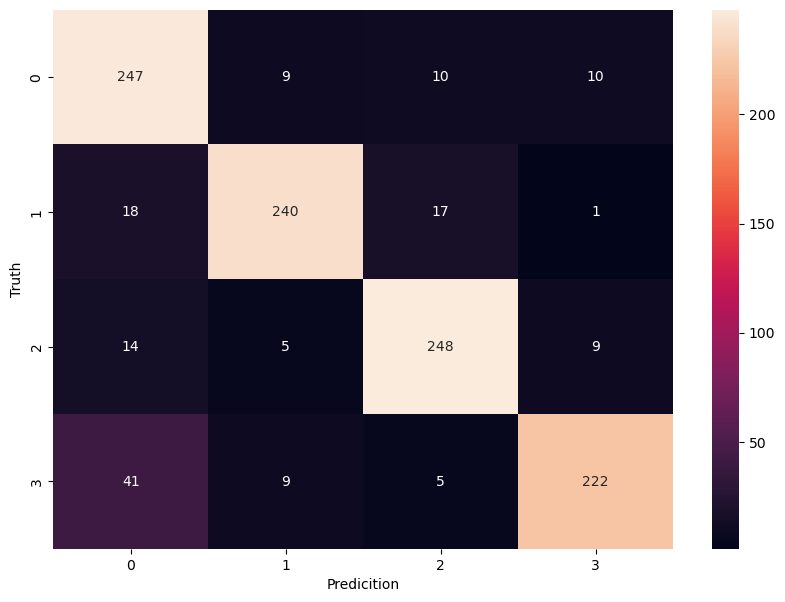

In [65]:
from matplotlib import pyplot as plt
import seaborn as sn
plt.figure(figsize=(10, 7))
sn.heatmap(cm, annot=True, fmt='d')
plt.xlabel('Predicition')
plt.ylabel('Truth')